<a href="https://colab.research.google.com/github/ktcraig/CryptoClustering/blob/main/Crypto_Clustering_starter_code_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
# Import required libraries and dependencies
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
!pip install hvplot
import hvplot.pandas

In [66]:
# Load the data into a Pandas DataFrame and make the index the "coin_id" column.
market_data_df = pd.read_csv("crypto_market_data.csv", index_col="coin_id")

# Display sample data
market_data_df.head(10)

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,1.08388,7.60278,6.57509,7.67258,-3.25185,83.51840,37.51761
ethereum,0.22392,10.38134,4.80849,0.13169,-12.88890,186.77418,101.96023
tether,-0.21173,0.04935,0.00640,-0.04237,0.28037,-0.00542,0.01954
ripple,-0.37819,-0.60926,2.24984,0.23455,-17.55245,39.53888,-16.60193
bitcoin-cash,2.90585,17.09717,14.75334,15.74903,-13.71793,21.66042,14.49384
binancecoin,2.10423,12.85511,6.80688,0.05865,36.33486,155.61937,69.69195
chainlink,-0.23935,20.69459,9.30098,-11.21747,-43.69522,403.22917,325.13186
cardano,0.00322,13.99302,5.55476,10.10553,-22.84776,264.51418,156.09756
litecoin,-0.06341,6.60221,7.28931,1.21662,-17.23960,27.49919,-12.66408


In [67]:
# Generate summary statistics
market_data_df.describe()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,-0.269686,4.497147,0.185787,1.545693,-0.094119,236.537432,347.667956
std,2.694793,6.375218,8.376939,26.344218,47.365803,435.225304,1247.842884
min,-13.527860,-6.094560,-18.158900,-34.705480,-44.822480,-0.392100,-17.567530
25%,-0.608970,0.047260,-5.026620,-10.438470,-25.907990,21.660420,0.406170
50%,-0.063410,3.296410,0.109740,-0.042370,-7.544550,83.905200,69.691950
75%,0.612090,7.602780,5.510740,4.578130,0.657260,216.177610,168.372510
max,4.840330,20.694590,24.239190,140.795700,223.064370,2227.927820,7852.089700


### Prepare the Data

In [68]:
# Use the `StandardScaler()` module from scikit-learn to normalize the data from the CSV file
scaled_data = StandardScaler().fit_transform(market_data_df)


In [69]:
# Create a DataFrame with the scaled data
scaled_df = pd.DataFrame(scaled_data, columns=market_data_df.columns)

# Copy the crypto names from the original data
scaled_df["coin_id"] = market_data_df.index

# Set the coinid column as index
scaled_df = scaled_df.set_index("coin_id")

# Display sample data
scaled_df.head()


,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317


### Find the Best Value for k Using the Original Scaled DataFrame.

In [70]:
# Create a list with the number of k-values to try
# Use a range from 1 to 11
k = list(range(1, 11))

# Create an empty list to store the inertia values
inertia = []

# Create a for loop to compute the inertia with each possible value of k
# Inside the loop:
# 1. Create a KMeans model using the loop counter for the n_clusters
# 2. Fit the model to the data using the scaled DataFrame
# 3. Append the model.inertia_ to the inertia list

for i in k:
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

# Create a dictionary with the data to plot the Elbow curve
elbow_data = {"k": k, "inertia": inertia}

# Create a DataFrame with the data to plot the Elbow curve
df_elbow = pd.DataFrame(elbow_data)

# Display the DataFrame
df_elbow


,k,inertia
0,1,287.000000
1,2,198.571818
2,3,145.635748
3,4,79.022435
4,5,66.217780
5,6,59.139070
6,7,48.406314
7,8,38.993588
8,9,34.400595
9,10,28.573603


Text(0.5, 1.0, 'Elbow Curve')

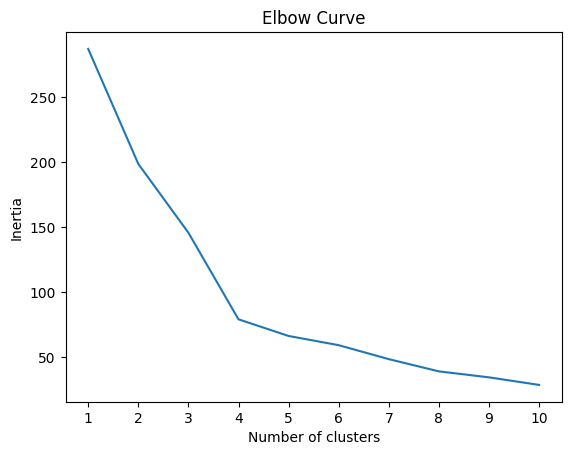

In [71]:
# Plot a line chart with all the inertia values computed with
# the different values of k to visually identify the optimal value for k.

import matplotlib.pyplot as plt

plt.plot(df_elbow['k'], df_elbow['inertia'])
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')


#### Answer the following question:
**Question:** What is the best value for `k`?

**Answer:** 4 is the best value

### Cluster Cryptocurrencies with K-means Using the Original Scaled Data.

In [72]:
# Initialize the K-Means model using the best value for k
model = KMeans(n_clusters=4, n_init='auto', random_state=1)


In [73]:
# Fit the K-Means model using the scaled data
model.fit(scaled_df)

KMeans(n_clusters=4, random_state=1)

In [74]:
# Predict the clusters to group the cryptocurrencies using the scaled data
predictions = model.predict(scaled_df)

# View the resulting array of cluster values.
print(predictions)

[2 2 0 0 2 2 2 2 2 0 0 0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 3 2 0 0 1
 0 0 0 0]


In [75]:
# Create a copy of the DataFrame
crypto_scaled_predictions = scaled_df.copy()

In [76]:
# Add a new column to the DataFrame with the predicted clusters
"""Source code: Gemini Assistance in Google Colab"""

crypto_scaled_predictions['cluster'] = model.labels_

# Display sample data
crypto_scaled_predictions.head()


,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y,cluster
coin_id,,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637,2
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352,2
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061,0
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546,0
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317,2


<Axes: xlabel='price_change_percentage_24h', ylabel='price_change_percentage_7d'>

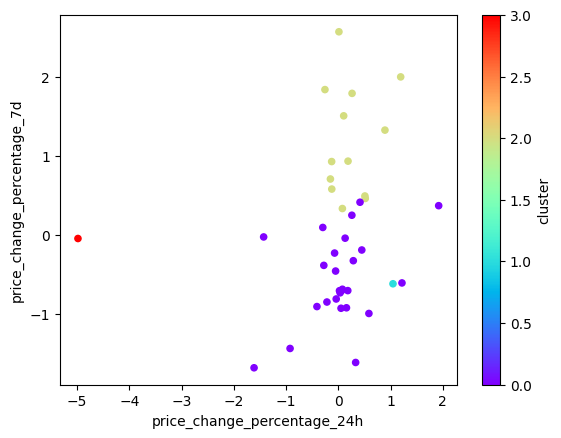

In [77]:
# Create a scatter plot using Pandas plot by setting
# `x="price_change_percentage_24h"` and `y="price_change_percentage_7d"`.
# Use "rainbow" for the color to better visualize the data.
crypto_scaled_predictions.plot.scatter(x="price_change_percentage_24h", y="price_change_percentage_7d", c="cluster", colormap="rainbow")


### Optimize Clusters with Principal Component Analysis.

In [78]:
# Create a PCA model instance and set `n_components=3`.
pca = PCA(n_components=3)


In [79]:
# Use the PCA model with `fit_transform` on the original scaled DataFrame to reduce to three principal components.
""""Source Code: Gemini Assistance in Google Colab"""
crypto_pca = pca.fit_transform(scaled_df)

# View the first five rows of the DataFrame
crypto_pca[:5]


array([[-0.60066733,  0.84276006,  0.46159457],
       [-0.45826071,  0.45846566,  0.95287678],
       [-0.43306981, -0.16812638, -0.64175193],
       [-0.47183495, -0.22266008, -0.47905316],
       [-1.15779997,  2.04120919,  1.85971527]])

In [80]:
# Retrieve the explained variance to determine how much information  can be attributed to each principal component
pca.explained_variance_ratio_


array([0.3719856 , 0.34700813, 0.17603793])

#### Answer the following question:

**Question:** What is the total explained variance of the three principal components?

**Answer:** 0.89503166

In [95]:
# Creating a DataFrame with the PCA data
pca_df = pd.DataFrame(
    data=crypto_pca, columns=["PCA1", "PCA2", "PCA3"]
)

# Copy the crypto names from the original data
pca_df["coin_id"] = market_data_df.index

# Set the coinid column as index
pca_df = pca_df.set_index("coin_id")

# Display sample data
pca_df.head()


,PCA1,PCA2,PCA3
coin_id,,,
bitcoin,-0.600667,0.842760,0.461595
ethereum,-0.458261,0.458466,0.952877
tether,-0.433070,-0.168126,-0.641752
ripple,-0.471835,-0.222660,-0.479053
bitcoin-cash,-1.157800,2.041209,1.859715


### Find the Best Value for k Using the PCA Data

In [96]:
# Create a list with the number of k-values to try
# Use a range from 1 to 11

k = list(range(1, 11))

# Create an empty list to store the inertia values
inertia = []


# Create a for loop to compute the inertia with each possible value of k
# Inside the loop:
# 1. Create a KMeans model using the loop counter for the n_clusters
# 2. Fit the model to the data using PCA DataFrame.
# 3. Append the model.inertia_ to the inertia list

for i in k:
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(pca_df)
    inertia.append(km.inertia_)

# Create a dictionary with the data to plot the Elbow curve
elbow_data = {"k": k, "inertia": inertia}

# Create a DataFrame with the data to plot the Elbow curve
df_elbow = pd.DataFrame(elbow_data)

# Display the DataFrame
df_elbow

,k,inertia
0,1,256.874086
1,2,168.811896
2,3,115.918077
3,4,49.665497
4,5,41.357314
5,6,30.796642
6,7,25.915457
7,8,21.890936
8,9,17.720699
9,10,13.838699


Text(0.5, 1.0, 'Elbow Curve')

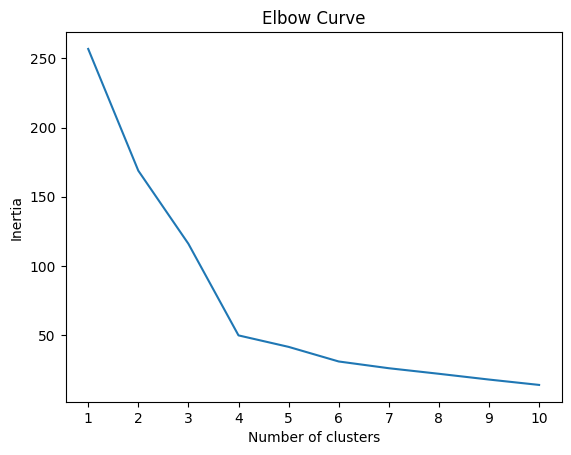

In [97]:
# Plot a line chart with all the inertia values computed with
# the different values of k to visually identify the optimal value for k.
""""Source Code: Gemini Assistance in Google Colab"""

plt.plot(df_elbow['k'], df_elbow['inertia'])
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')


#### Answer the following questions:
* **Question:** What is the best value for `k` when using the PCA data?

  * **Answer:** 4


* **Question:** Does it differ from the best k value found using the original data?

  * **Answer:**  No

### Cluster Cryptocurrencies with K-means Using the PCA Data

In [98]:
# Initialize the K-Means model using the best value for k
model = KMeans(n_clusters=4, n_init='auto', random_state=1)

In [99]:
# Fit the K-Means model using the PCA data
model.fit(pca_df)


KMeans(n_clusters=4, random_state=1)

In [100]:
# Predict the clusters to group the cryptocurrencies using the PCA data
predictions = model.predict(pca_df)

# Print the resulting array of cluster values
print(predictions)


[2 2 0 0 2 2 2 2 2 0 0 0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 3 2 0 0 1
 0 0 0 0]


In [101]:
# Create a copy of the DataFrame with the PCA data
clustered_df = pca_df.copy()

# Add a new column to the DataFrame with the predicted clusters
clustered_df['cluster'] = model.labels_

# Reset index
clustered_df = clustered_df.reset_index()

# Set index to "coin_id"
clustered_df = clustered_df.set_index("coin_id")

# Display sample data
clustered_df.head()




,PCA1,PCA2,PCA3,cluster
coin_id,,,,
bitcoin,-0.600667,0.842760,0.461595,2
ethereum,-0.458261,0.458466,0.952877,2
tether,-0.433070,-0.168126,-0.641752,0
ripple,-0.471835,-0.222660,-0.479053,0
bitcoin-cash,-1.157800,2.041209,1.859715,2


In [103]:
# Create a scatter plot using hvPlot by setting `x="PCA1"` and `y="PCA2"`
"""Source code: Gemini Assistance in Google Colab"""

clustered_df.hvplot.scatter(x="PCA1", y="PCA2", by="cluster")

:NdOverlay   [cluster]
   :Scatter   [PCA1]   (PCA2)

### Determine the Weights of Each Feature on each Principal Component

In [111]:
# Use the columns from the original scaled DataFrame as the index.
pca = PCA(n_components=2)
pca.fit(scaled_df)
pca_component_weights = pd.DataFrame(pca.components_.T, columns=['PCA1', 'PCA2'], index=scaled_df.columns)
pca_component_weights

,PCA1,PCA2
price_change_percentage_24h,-0.416728,0.358162
price_change_percentage_7d,-0.102432,0.227432
price_change_percentage_14d,-0.009162,0.540415
price_change_percentage_30d,0.191523,0.562182
price_change_percentage_60d,0.320365,0.434040
price_change_percentage_200d,0.594468,0.027735
price_change_percentage_1y,0.568379,-0.150789


#### Answer the following question:

* **Question:** Which features have the strongest positive or negative influence on each component?

* **Answer:**
"price_change_percentage_30d" and "price_change_percentage_60d" have the strongest positive influence on PCA1. "price_change_percentage_24h" has the strongest negative influence on PCA1.
"price_change_percentage_60d" has the strongest positive influence on PCA2.  